# Final Exam Score Prediction using Computational Graph

**Task:** Predict final exam scores from midterm scores using **Linear Regression** with **PyTorch autograd** and **manual Gradient Descent**.

- Model: `y_hat = w * x + b`
- Loss: MSE (Mean Squared Error)
- Learning rate: 0.01
- Dataset: `Data/TRAIN2.xlsx`

## 1. Problem Statement

| Item | Detail |
|------|--------|
| **Input (x)** | Midterm score |
| **Output (y)** | Final score |
| **Model** | Linear Regression: `y_hat = w * x + b` |
| **Loss** | MSE = mean((y - y_hat)²) |
| **Learning rate** | 0.01 |
| **Goal** | Find trained values of **w** and **b** |

## 2. Method

1. **Forward pass:** compute `y_hat = w * x + b` and `MSE = mean((y - y_hat)²)`
2. **Backward pass:** call `MSE.backward()` — PyTorch builds the computational graph and computes gradients `∂MSE/∂w` and `∂MSE/∂b` automatically
3. **Update:** Gradient Descent manually updates the parameters:
   ```
   w = w - lr * w.grad
   b = b - lr * b.grad
   ```
4. Repeat for many epochs until the loss converges.

## 3. Import Libraries

In [5]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import os

## 4. Load Dataset

In [6]:
# Resolve path relative to the notebook location
data_path = os.path.join(os.path.dirname(os.getcwd()), 'Data', 'TRAIN2.xlsx')
if not os.path.exists(data_path):
    # Fallback: maybe running from repository root
    data_path = os.path.join('Data', 'TRAIN2.xlsx')

df = pd.read_excel(data_path)

# Normalize column names to lowercase, strip whitespace
df.columns = df.columns.str.strip().str.lower()

print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Dataset shape: (515, 2)
Columns: ['final', 'midterm']


,final,midterm
0,2.56,0.70
1,2.78,0.97
2,6.35,5.43
3,5.99,4.99
4,7.67,7.09


## 5. Convert to PyTorch Tensors

In [7]:
X = torch.tensor(df['midterm'].values, dtype=torch.float32).view(-1, 1)  # input
Y = torch.tensor(df['final'].values,   dtype=torch.float32).view(-1, 1)  # label

print(f'X shape: {X.shape}')  # (N, 1)
print(f'Y shape: {Y.shape}')  # (N, 1)

X shape: torch.Size([515, 1])
Y shape: torch.Size([515, 1])


## 6. Initialize Parameters

In [8]:
# Trainable parameters initialized to 0
w = torch.tensor([[0.0]], requires_grad=True)
b = torch.tensor([[0.0]], requires_grad=True)

print(f'Initial w = {w.item():.4f}')
print(f'Initial b = {b.item():.4f}')

Initial w = 0.0000
Initial b = 0.0000


## 7. Training Loop

In [9]:
learning_rate = 0.01
epochs = 2000
mse_history = []

for epoch in range(1, epochs + 1):
    # --- Forward pass ---
    y_hat = w * X + b                       # prediction
    loss = ((Y - y_hat) ** 2).mean()        # MSE

    # --- Backward pass (computational graph) ---
    loss.backward()                         # compute gradients

    # --- Gradient Descent update ---
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

    # Reset gradients for next epoch
    w.grad.zero_()
    b.grad.zero_()

    # Record loss
    mse_history.append(loss.item())

    # Print progress every 200 epochs
    if epoch % 200 == 0 or epoch == 1:
        print(f'Epoch {epoch:>5d} | MSE = {loss.item():.4f} | w = {w.item():.4f} | b = {b.item():.4f}')

Epoch     1 | MSE = 41.8715 | w = 0.7448 | b = 0.1207
Epoch   200 | MSE = 0.1194 | w = 0.9024 | b = 1.3173
Epoch   400 | MSE = 0.0165 | w = 0.8381 | b = 1.7474
Epoch   600 | MSE = 0.0023 | w = 0.8142 | b = 1.9072
Epoch   800 | MSE = 0.0003 | w = 0.8053 | b = 1.9667
Epoch  1000 | MSE = 0.0001 | w = 0.8020 | b = 1.9888
Epoch  1200 | MSE = 0.0000 | w = 0.8008 | b = 1.9970
Epoch  1400 | MSE = 0.0000 | w = 0.8003 | b = 2.0000
Epoch  1600 | MSE = 0.0000 | w = 0.8001 | b = 2.0012
Epoch  1800 | MSE = 0.0000 | w = 0.8001 | b = 2.0016
Epoch  2000 | MSE = 0.0000 | w = 0.8001 | b = 2.0017


## 8. Final Results

In [10]:
print('=' * 50)
print(f'  Trained w           = {w.item():.4f}')
print(f'  Trained b           = {b.item():.4f}')
print(f'  Final Training MSE  = {mse_history[-1]:.4f}')
print('=' * 50)
print(f'\n  Prediction function:')
print(f'  final_score = {w.item():.4f} * midterm_score + {b.item():.4f}')

  Trained w           = 0.8001
  Trained b           = 2.0017
  Final Training MSE  = 0.0000

  Prediction function:
  final_score = 0.8001 * midterm_score + 2.0017


## 9. Demo: Predict & Compare

In [11]:
# Predict on the entire dataset
with torch.no_grad():
    Y_pred = w * X + b

# Show 5 sample predictions
demo = pd.DataFrame({
    'midterm':        X[:5].squeeze().tolist(),
    'actual_final':   Y[:5].squeeze().tolist(),
    'predicted_final': Y_pred[:5].squeeze().tolist()
})
demo

,midterm,actual_final,predicted_final
0,0.70,2.56,2.561781
1,0.97,2.78,2.777795
2,5.43,6.35,6.346032
3,4.99,5.99,5.994009
4,7.09,7.67,7.674120


### MSE Loss Curve

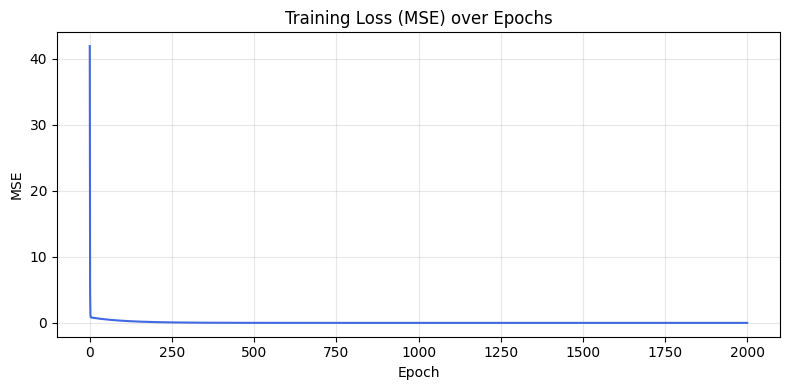

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(mse_history, color='royalblue')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Training Loss (MSE) over Epochs')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Regression Line

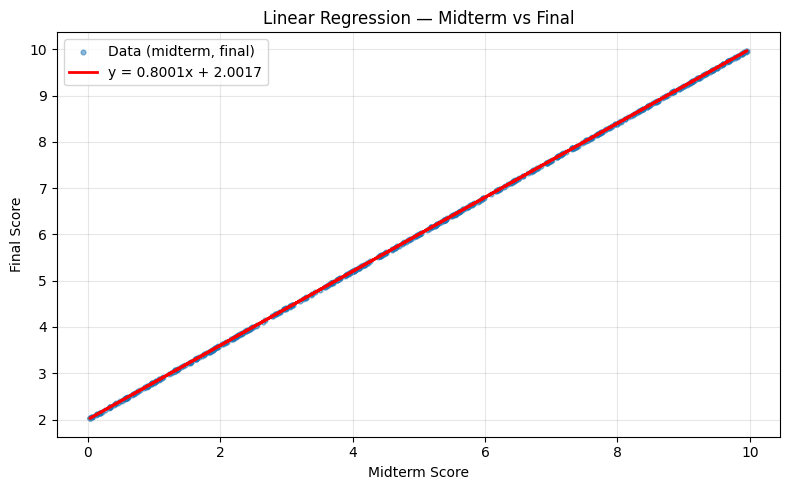

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(X.numpy(), Y.numpy(), s=12, alpha=0.5, label='Data (midterm, final)')
plt.plot(X.numpy(), Y_pred.numpy(), color='red', linewidth=2, label=f'y = {w.item():.4f}x + {b.item():.4f}')
plt.xlabel('Midterm Score')
plt.ylabel('Final Score')
plt.title('Linear Regression — Midterm vs Final')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Explanation

- **Initialization:** `w = 0`, `b = 0` → the model starts by predicting 0 for every input, so the initial loss is high.
- **MSE** measures the average squared error across all samples. A smaller MSE means better predictions.
- **`loss.backward()`** uses the **computational graph** built by PyTorch during the forward pass to compute `∂MSE/∂w` and `∂MSE/∂b` automatically (autograd).
- **Gradient Descent** moves `w` and `b` in the direction that reduces MSE:
  ```
  w = w - lr * ∂MSE/∂w
  b = b - lr * ∂MSE/∂b
  ```
- After enough epochs, `w` and `b` converge to stable values that define the best linear prediction function.